## 7. Group Assignment & Presentation


__You should be able to start up on this exercise after Lecture 1.__

*This exercise must be a group effort. That means everyone must participate in the assignment.*

In this assignment you will solve a data science problem end-to-end, pretending to be recently hired data scientists in a company. To help you get started, we've prepared a checklist to guide you through the project. Here are the main steps that you will go through:

3. Explore and visualise the data to gain insights
4. Prepare the data to better expose the underlying data patterns to machine learning algorithms
5. Explore many different models and short-list the best ones
6. Fine-tune your models
7. Present your solution (video presentation) 

In each step we list a set of questions that one should have in mind when undertaking a data science project. The list is not meant to be exhaustive, but does contain a selection of the most important questions to ask. We will be available to provide assistance with each of the steps, and will allocate some part of each lesson towards working on the projects.

Your group must submit a _**single**_ Jupyter notebook, structured in terms of the first 6 sections listed above (the seventh will be a video uploaded to some streaming platform, e.g. YouTube, Vimeo, etc.).

### 3. Explore the data
1. Create a copy of the data for explorations (sampling it down to a manageable size if necessary)
2. Create a Jupyter notebook to keep a record of your data exploration
3. Study each feature and its characteristics:
    * Name
    * Type (categorical, int/float, bounded/unbounded, text, structured, etc)
    * Percentage of missing values
    * Check for outliers, rounding errors etc
4. For supervised learning tasks, identify the target(s)
5. Visualise the data
6. Study the correlations between features
7. Identify the promising transformations you may want to apply (e.g. convert skewed targets to normal via a log transformation)
8. Document what you have learned
### 4. Prepare the data
Notes:
* Work on copies of the data (keep the original dataset intact).
* Write functions for all data transformations you apply, for three reasons:
    * So you can easily prepare the data the next time you run your code
    * So you can apply these transformations in future projects
    * To clean and prepare the test set
    
    
1. Data cleaning:
    * Fix or remove outliers (or keep them)
    * Fill in missing values (e.g. with zero, mean, median, regression ...) or drop their rows (or columns)
2. Feature selection (optional):
    * Drop the features that provide no useful information for the task (e.g. a customer ID is usually useless for modelling).
3. Feature engineering, where appropriate:
    * Discretize continuous features
    * Use one-hot encoding if/when relevant
    * Add promising transformations of features (e.g. $\log(x)$, $\sqrt{x}$, $x^2$, etc)
    * Aggregate features into promising new features
4. Feature scaling: standardise or normalise features
### 5. Short-list promising models
We expect you to do some additional research and train at **least one model per team member**.

1. Train mainly quick and dirty models from different categories (e.g. linear, SVM, Random Forests etc) using default parameters
2. Measure and compare their performance
3. Analyse the most significant variables for each algorithm
4. Analyse the types of errors the models make
5. Have a quick round of feature selection and engineering if necessary
6. Have one or two more quick iterations of the five previous steps
7. Short-list the top three to five most promising models, preferring models that make different types of errors
### 6. Fine-tune the system
1. Fine-tune the hyperparameters
2. Once you are confident about your final model, measure its performance on the test set to estimate the generalisation error
### 7. Present your solution
1. Document what you have done
2. Create a nice 15 minute video presentation with slides
    * Make sure you highlight the big picture first
3. Explain why your solution achieves the business objective
4. Don't forget to present interesting points you noticed along the way:
    * Describe what worked and what did not
    * List your assumptions and you model's limitations
5. Ensure your key findings are communicated through nice visualisations or easy-to-remember statements (e.g. "the median income is the number-one predictor of housing prices")
6. Upload the presentation to some online platform, e.g. YouTube or Vimeo, and supply a link to the video in the notebook.
Géron, A. 2017, *Hands-On Machine Learning with Scikit-Learn and Tensorflow*, Appendix B, O'Reilly Media, Inc., Sebastopol.

# Research, reasons for no show health care appointments.

## 1. Framing the Problem and looking at the bigger picture.

### Objective:
Predict and analyze healthcare appointment no-shows, focusing on economic and demographic factors that might influence them.

#### Key Questions with Demographics:
- What economic factors (e.g., income, unemployment rate, access to transportation) correlate with no-shows?
- Are there specific patterns in different Brazilian cities or regions?
- Do specific age groups (like the elderly or youth) show higher no-show rates?
- How does education or literacy correlate with appointment attendance?
- Are there patterns in no-shows based on gender or ethnicity in different cities?
- Is family structure (e.g., single parents vs. larger households) a factor?

#### Scope Expansion:
- Geographical Focus: Cities in Brazil (urban/rural divide? Large vs. small cities?).
- Economic Focus: Indicators like GDP per capita, public health investment, and local employment rates.
- Healthcare Metrics: Number of appointments, no-show rates, reasons for no-shows.
- Income brackets.
- Local employment levels.
- Urbanization metrics.

#### Feature Engineering for Demographics:
- Combine Age (from the healthcare dataset) with IDHM_Renda or GDP_CAPITA (from the Brazil cities dataset) to explore how income levels vary by age group.
- Create a composite variable for Neighbourhood-level healthcare data and RURAL_URBAN classification to highlight urban-rural divides.
- Group cities by demographic trends (e.g., predominantly elderly populations).
- Group cities based on IDHM scores to categorize them into high, medium, and low human development zones.

#### Insights from Demographic-Economic Analysis:
- Identify high no-show rates in low-income areas by linking Neighbourhood data with GDP_CAPITA or IDHM_Renda.
- Highlight rural cities (RURAL_URBAN = "Rural") with low MUN_EXPENDIT for targeted healthcare funding.

## 2. Get the Data  
The healthcare no-show data was sourced from Kaggle, providing a clean and well-organized dataset. After a quick exploration of the dataset, we thought it would be interesting to investigate potential correlations with Brazil's economic and demographic aspects. To support this, we located another dataset containing information about Brazilian cities, though it requires significant cleaning and preprocessing due to its raw state.

## 3. Explore the data

#### 3.1 Imports

In [ ]:
# !pip install plotly
# !pip install nbformat
# !pip install geopandas contextily
# !pip install osmnx

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import osmnx as ox
from sklearn import preprocessing

#### 3.2 Data set loading

In [33]:
df_appointments = pd.read_csv('healthcare-noshow/healthcare_noshows_appt.csv')
df_cities = pd.read_csv('cities/BRAZIL_CITIES_REV2022.csv')

#### 3.3 Study the features and characteristics

In [ ]:
def study_features(df):
    feature_summary = []
    for column in df.columns:
        col_type = df[column].dtype
        feature_type = (
            "Categorical" if col_type == "object" else "Numerical"
        ) if col_type in ["object", "int64", "float64"] else "Other"
        
        # Feature analysis
        feature_info = {
            "Feature Name": column,
            "Type": feature_type,
            "Missing Values (%)": df[column].isnull().mean() * 100,
            "Unique Values": len(df[column].unique()),
        }
        
        # Add numeric details if applicable
        if feature_type == "Numerical":
            feature_info.update({
                "Min": df[column].min(),
                "Max": df[column].max(),
                "Mean": df[column].mean(),
                "Std Dev": df[column].std(),
            })
            
            # Check for outliers using IQR
            q1 = df[column].quantile(0.25)
            q3 = df[column].quantile(0.75)
            iqr = q3 - q1
            outliers = df[(df[column] < (q1 - 1.5 * iqr)) | (df[column] > (q3 + 1.5 * iqr))]
            feature_info["Outliers (Count)"] = len(outliers)
        
        feature_summary.append(feature_info)
    
    return pd.DataFrame(feature_summary)

healthcare_feature_summary = study_features(df_appointments)
display(healthcare_feature_summary)

# Analyze the cities dataset
cities_feature_summary = study_features(df_cities)
display(cities_feature_summary)


      Feature Name         Type  Missing Values (%)  Unique Values  \
0        PatientId    Numerical                 0.0          60270   
1    AppointmentID    Numerical                 0.0         106987   
2           Gender  Categorical                 0.0              2   
3     ScheduledDay  Categorical                 0.0            110   
4   AppointmentDay  Categorical                 0.0             27   
5              Age    Numerical                 0.0            102   
6    Neighbourhood  Categorical                 0.0             81   
7      Scholarship        Other                 0.0              2   
8     Hipertension        Other                 0.0              2   
9         Diabetes        Other                 0.0              2   
10      Alcoholism        Other                 0.0              2   
11         Handcap        Other                 0.0              2   
12    SMS_received        Other                 0.0              2   
13       Showed_up  

1. Motorcycles per capita (-0.357): Higher motorcycle ownership suggests middle-class areas with better transportation access. In Brazil, motorcycles are often a first vehicle purchase for working-class families, indicating areas where people have means to get to appointments.

2. Altitude (0.279): Higher altitude areas in Brazil often correspond to more remote or mountainous regions with less developed infrastructure and harder access to healthcare facilities.

3. Post offices per capita (-0.217): In Brazil, post office density indicates urban development and government service presence. Better-served areas show lower no-show rates.

4. Fixed phones per capita (0.204): Interestingly positive correlation. May indicate older, possibly retired populations who have landlines but might have mobility issues.

5. Area (-0.125): Larger areas typically mean more rural settings in Brazil. Negative correlation suggests rural patients, once they commit to appointments, are more likely to show up.

6. IDHM metrics (small correlations): The Human Development Index components show weak correlations, suggesting socioeconomic factors might be less important than infrastructure and accessibility.

7. Healthcare companies per capita (0.055): Minimal correlation suggests availability of healthcare facilities isn't a major factor in no-shows

### 1.Imports

In [35]:
# display(df_appointments.head())
# display(df_appointments.info())
# display(df_appointments.describe())
# display(df_appointments.shape)

# print("\nCities Dataset:\n")
# display(df_cities.head())
# display(df_cities.info())
# display(df_cities.describe())
# display(df_cities.shape)

In [36]:
# Standardize both datasets
df_appointments['City_Name'] = df_appointments['Neighbourhood'].str.title()
df_cities['City_Std'] = df_cities['CITY'].str.upper()

# Check duplicates in cities
city_duplicates = df_cities[df_cities.duplicated(subset=['CITY'], keep=False)]
print("Duplicate city counts:")
print(city_duplicates['CITY'].value_counts())

# Which state(s) is your appointments data from?
print("\nUnique neighborhoods:")
print(df_appointments['Neighbourhood'].nunique())

Duplicate city counts:
CITY
Bom Jesus          5
São Domingos       5
Bonito             4
Planalto           4
Santa Terezinha    4
                  ..
Viana              2
Várzea             2
Várzea Grande      2
Wenceslau Braz     2
Água Boa           2
Name: count, Length: 237, dtype: int64

Unique neighborhoods:
81


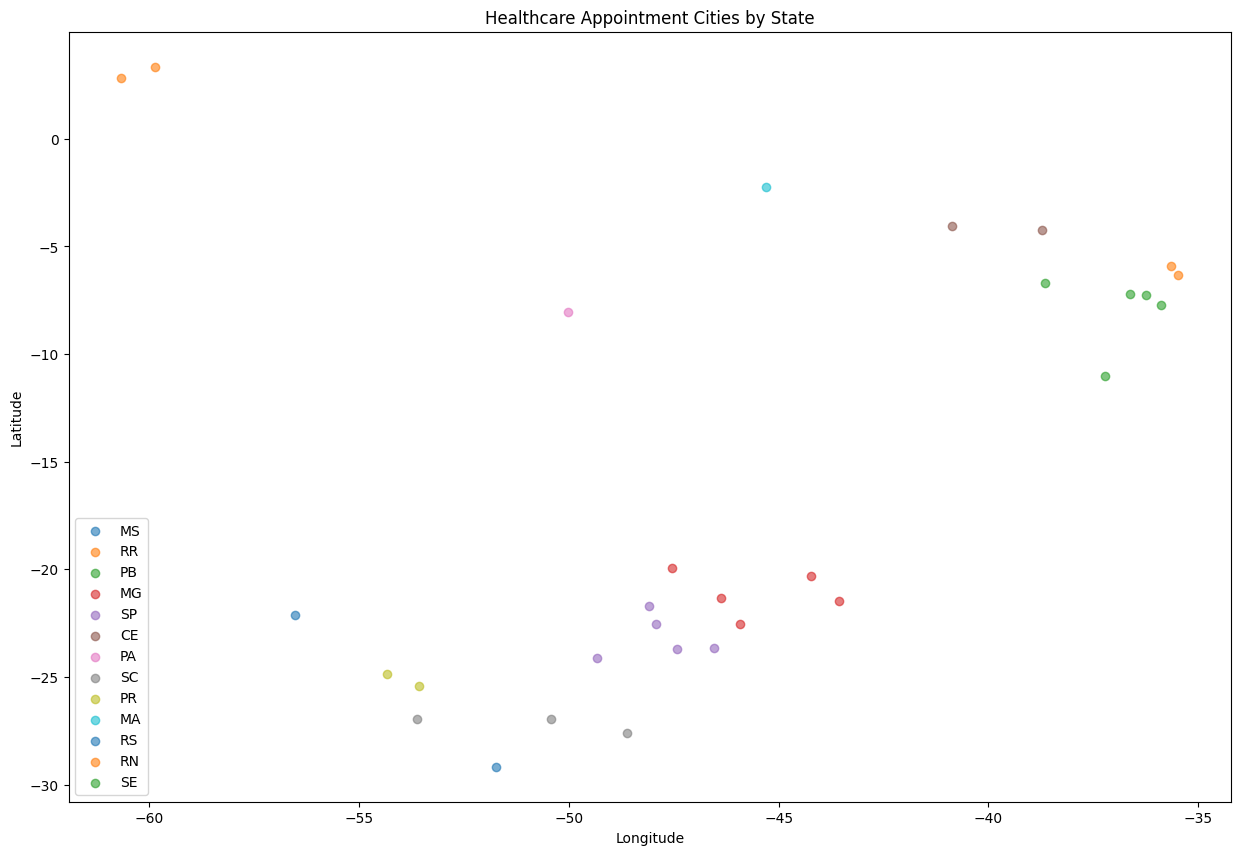

Cities found: 30

Cities by state:
STATE
SP    5
MG    5
PB    4
SC    3
RR    2
PR    2
CE    2
RN    2
MS    1
PA    1
MA    1
RS    1
SE    1
Name: count, dtype: int64


In [37]:
appointment_cities = df_appointments['Neighbourhood'].unique()
appointment_cities_title = [city.title() for city in appointment_cities]
mapped_cities = df_cities[df_cities['CITY'].isin(appointment_cities_title)]

plt.figure(figsize=(15,10))
for state in mapped_cities['STATE'].unique():
    state_data = mapped_cities[mapped_cities['STATE'] == state]
    plt.scatter(state_data['LONG'], state_data['LAT'], label=state, alpha=0.6)

plt.legend()
plt.title('Healthcare Appointment Cities by State')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

print(f"Cities found: {len(mapped_cities)}")
print("\nCities by state:")
print(mapped_cities['STATE'].value_counts())

C:\Users\drago\AppData\Local\Temp\ipykernel_49052\2500137447.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapped_cities['appointment_count'] = mapped_cities['CITY'].apply(
C:\Users\drago\AppData\Local\Temp\ipykernel_49052\2500137447.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapped_cities['duplicate_group'] = mapped_cities['CITY'].map(


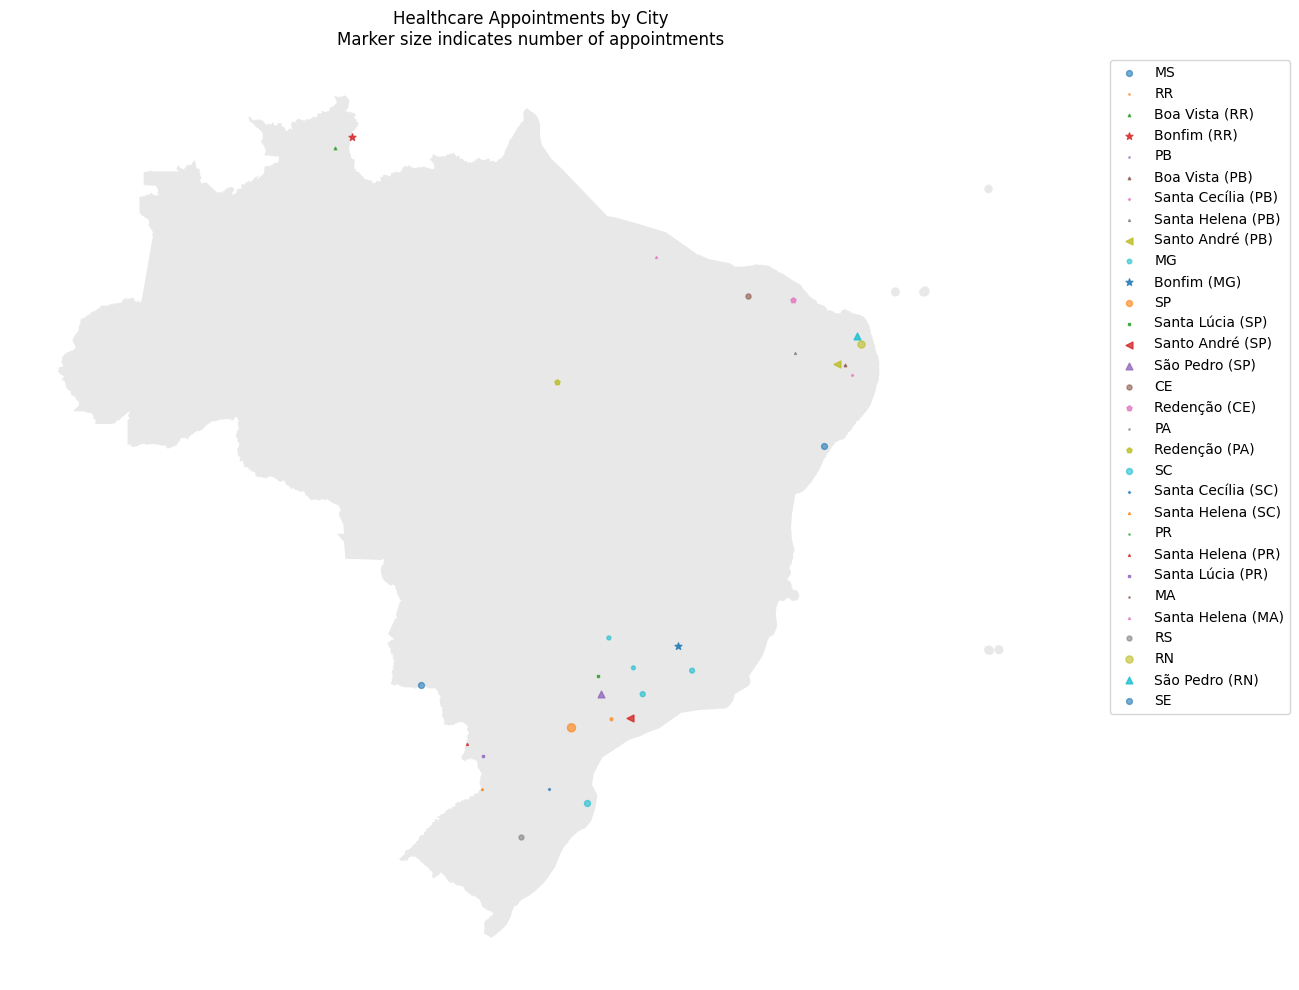

In [38]:
# Get Brazil geometry and prepare data
brazil = ox.geocode_to_gdf('Brazil')
city_duplicates = df_cities[df_cities.duplicated(subset=['CITY'], keep=False)]

# Count appointments per neighborhood
appointment_counts = df_appointments['Neighbourhood'].value_counts()

# Prepare mapped cities with appointment counts
mapped_cities = df_cities[df_cities['CITY'].isin([c.title() for c in appointment_counts.index])]
mapped_cities['appointment_count'] = mapped_cities['CITY'].apply(
   lambda x: appointment_counts.get(x.upper(), 0)
)
mapped_cities['duplicate_group'] = mapped_cities['CITY'].map(
   {city: idx for idx, city in enumerate(city_duplicates['CITY'].unique())}
)

# Markers for different duplicate groups
markers = ['*', 'P', 'D', 'X', '^', '<', '>', 'v', 's', 'p']

# Create plot
fig, ax = plt.subplots(figsize=(15, 10))
brazil.plot(ax=ax, alpha=0.5, color='lightgray')

# Plot cities
for state in mapped_cities['STATE'].unique():
   state_data = mapped_cities[mapped_cities['STATE'] == state]
   
   # Non-duplicates
   non_dup = state_data[state_data['duplicate_group'].isna()]
   plt.scatter(non_dup['LONG'], non_dup['LAT'], 
              s=non_dup['appointment_count']/100,  # Size based on appointments
              label=f"{state}", alpha=0.6)
   
   # Duplicates with different markers
   for group in state_data['duplicate_group'].dropna().unique():
       dup = state_data[state_data['duplicate_group'] == group]
       marker = markers[int(group % len(markers))]
       plt.scatter(dup['LONG'], dup['LAT'], 
                  s=dup['appointment_count']/100,  # Size based on appointments
                  marker=marker, 
                  label=f"{dup['CITY'].iloc[0]} ({state})", 
                  alpha=0.8)

# Add hover annotations
annot = ax.annotate("", xy=(0,0), xytext=(10,10), textcoords="offset points",
                   bbox=dict(boxstyle="round", fc="w", alpha=0.8))
annot.set_visible(False)

def hover(event):
   if event.inaxes == ax:
       for collection in ax.collections:
           cont, ind = collection.contains(event)
           if cont:
               pos = collection.get_offsets()[ind["ind"][0]]
               city_data = mapped_cities[(mapped_cities['LONG'] == pos[0]) & 
                                      (mapped_cities['LAT'] == pos[1])].iloc[0]
               text = (f"City: {city_data['CITY']}\n"
                      f"State: {city_data['STATE']}\n"
                      f"Appointments: {city_data['appointment_count']:,}")
               if not np.isnan(city_data.get('duplicate_group', np.nan)):
                   text += f"\nPart of duplicate group {int(city_data['duplicate_group'])}"
               annot.xy = pos
               annot.set_text(text)
               annot.set_visible(True)
               fig.canvas.draw_idle()
               return
       annot.set_visible(False)
       fig.canvas.draw_idle()

fig.canvas.mpl_connect("motion_notify_event", hover)

plt.title('Healthcare Appointments by City\nMarker size indicates number of appointments')
ax.axis('off')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\drago\AppData\Local\Temp\ipykernel_49052\3162690909.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapped_cities['appointment_count'] = mapped_cities['CITY'].apply(


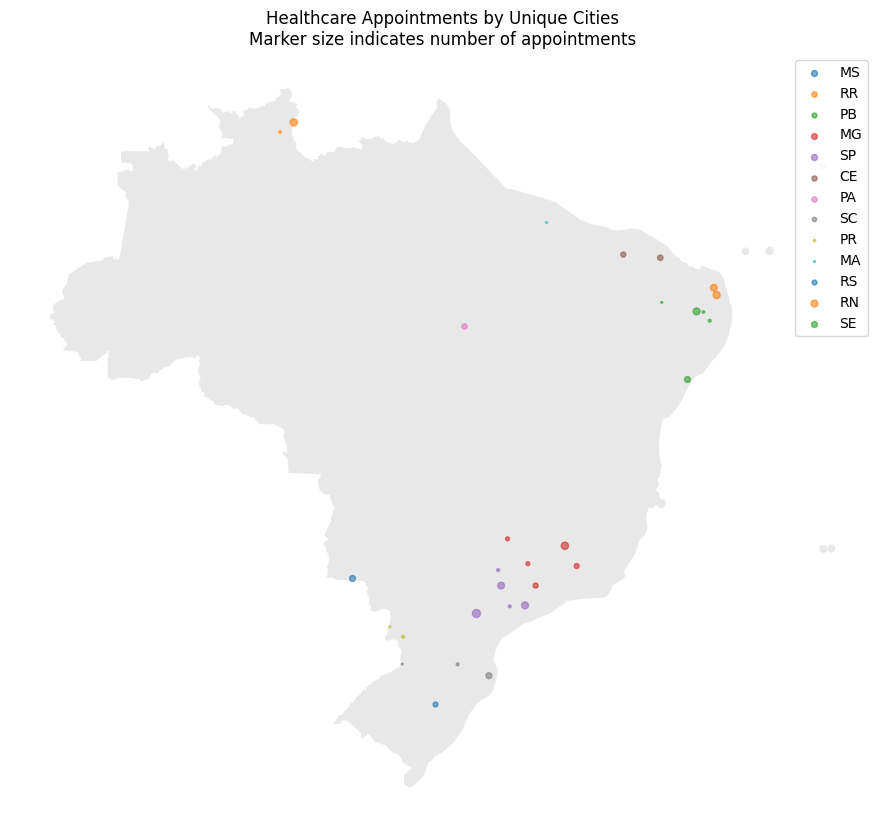

Unique cities mapped: 30


In [39]:
# Get Brazil map
brazil = ox.geocode_to_gdf('Brazil')

# Get unique neighborhoods and count appointments
unique_neighborhoods = df_appointments['Neighbourhood'].unique()
appointment_counts = df_appointments['Neighbourhood'].value_counts()

# Create mapping DataFrame
mapped_cities = df_cities[df_cities['CITY'].isin([n.title() for n in unique_neighborhoods])]
mapped_cities['appointment_count'] = mapped_cities['CITY'].apply(
   lambda x: appointment_counts.get(x.upper(), 0)
)

# Plot
fig, ax = plt.subplots(figsize=(15, 10))
brazil.plot(ax=ax, alpha=0.5, color='lightgray')

for state in mapped_cities['STATE'].unique():
   state_data = mapped_cities[mapped_cities['STATE'] == state]
   plt.scatter(state_data['LONG'], state_data['LAT'], 
              s=state_data['appointment_count']/100,
              label=state, alpha=0.6)

# Hover functionality
annot = ax.annotate("", xy=(0,0), xytext=(10,10), textcoords="offset points",
                   bbox=dict(boxstyle="round", fc="w", alpha=0.8))
annot.set_visible(False)

def hover(event):
   if event.inaxes == ax:
       for collection in ax.collections:
           cont, ind = collection.contains(event)
           if cont:
               pos = collection.get_offsets()[ind["ind"][0]]
               city_data = mapped_cities[(mapped_cities['LONG'] == pos[0]) & 
                                      (mapped_cities['LAT'] == pos[1])].iloc[0]
               text = (f"City: {city_data['CITY']}\n"
                      f"State: {city_data['STATE']}\n"
                      f"Appointments: {city_data['appointment_count']:,}")
               annot.xy = pos
               annot.set_text(text)
               annot.set_visible(True)
               fig.canvas.draw_idle()
               return
       annot.set_visible(False)
       fig.canvas.draw_idle()

fig.canvas.mpl_connect("motion_notify_event", hover)

plt.title('Healthcare Appointments by Unique Cities\nMarker size indicates number of appointments')
ax.axis('off')
plt.legend()
plt.show()

print(f"Unique cities mapped: {len(mapped_cities)}")

Top 10 features correlated with no-show rates:
ALT: 0.279
Pr_Bank: 0.158
Motorcycles: -0.152
AREA: -0.125
MUN_EXPENDIT: -0.071
ESTIMATED_POP: -0.070
Pu_Assets: -0.066
Pu_Bank: -0.065
POP_GDP: -0.064
HOTELS: -0.062


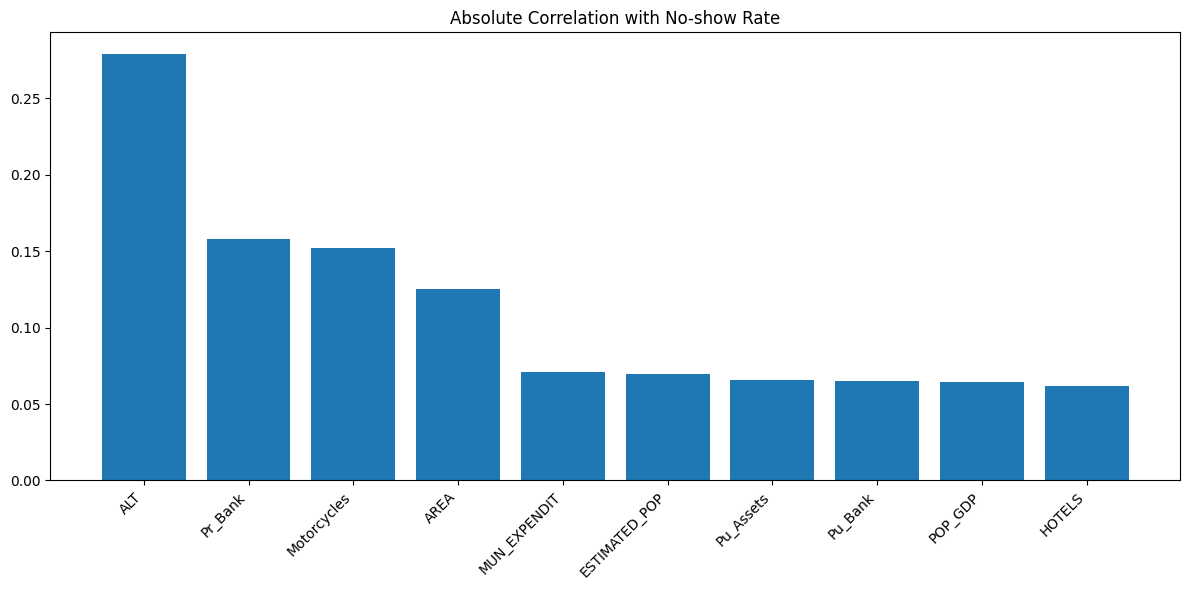

In [40]:
# Select meaningful features, excluding redundant or administrative ones
features_to_analyze = [
   'IDHM', 'IDHM_Renda', 'IDHM_Longevidade', 'IDHM_Educacao',
   'GDP_CAPITA', 'GDP', 'GVA_TOTAL', 
   'FIXED_PHONES', 'PAY_TV',
   'Pr_Bank', 'Pu_Bank', 'Pr_Assets', 'Pu_Assets',
   'POST_OFFICES', 'HOTELS', 'BEDS',
   'IBGE_RES_POP', 'ESTIMATED_POP', 'POP_GDP',
   'Cars', 'Motorcycles',
   'AREA', 'ALT',
   'COMP_TOT', 'COMP_Q',  # Total companies and healthcare companies
   'MUN_EXPENDIT'
]

# Calculate no-show rates and merge
no_show_rates = df_appointments.groupby('Neighbourhood').agg({
   'Showed_up': lambda x: (~x).mean()
}).reset_index()
no_show_rates.columns = ['CITY', 'no_show_rate']
no_show_rates['CITY'] = no_show_rates['CITY'].str.title()
city_features = pd.merge(no_show_rates, df_cities, on='CITY', how='left')

# Calculate and display correlations
correlations = {feature: city_features['no_show_rate'].corr(city_features[feature]) 
              for feature in features_to_analyze if city_features[feature].dtype in ['float64', 'int64']}
correlations_sorted = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True))

print("Top 10 features correlated with no-show rates:")
for feature, corr in list(correlations_sorted.items())[:10]:
   print(f"{feature}: {corr:.3f}")

# Visualize top correlations
plt.figure(figsize=(12, 6))
plt.bar(list(correlations_sorted.keys())[:10], [abs(v) for v in correlations_sorted.values()][:10])
plt.xticks(rotation=45, ha='right')
plt.title('Absolute Correlation with No-show Rate')
plt.tight_layout()
plt.show()

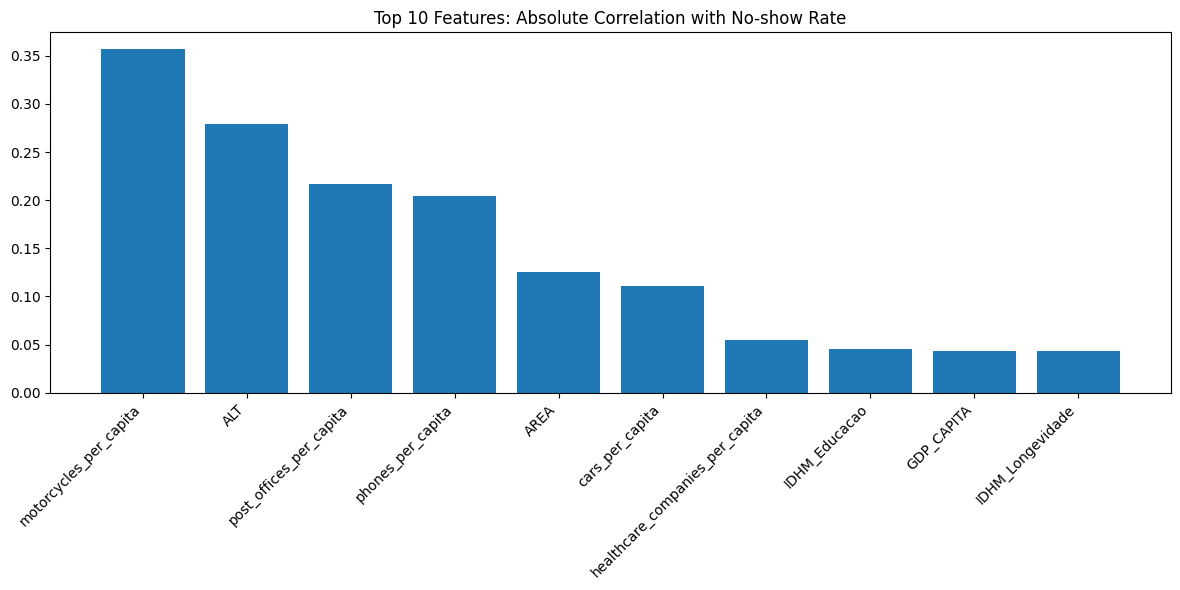


Correlations (positive means higher no-show rate):
motorcycles_per_capita: -0.357
ALT: 0.279
post_offices_per_capita: -0.217
phones_per_capita: 0.204
AREA: -0.125
cars_per_capita: 0.111
healthcare_companies_per_capita: 0.055
IDHM_Educacao: 0.045
GDP_CAPITA: -0.044
IDHM_Longevidade: -0.043
IDHM_Renda: 0.026
hotels_per_capita: -0.026
IDHM: 0.024
paytv_per_capita: -0.011
banks_per_capita: -0.004


In [41]:
# Calculate per capita metrics
def add_per_capita(df):
   pop = df['IBGE_RES_POP'].replace(0, np.nan)  # Avoid division by zero
   return df.assign(
       cars_per_capita=df['Cars'] / pop,
       motorcycles_per_capita=df['Motorcycles'] / pop,
       banks_per_capita=(df['Pr_Bank'] + df['Pu_Bank']) / pop,
       healthcare_companies_per_capita=df['COMP_Q'] / pop,
       hotels_per_capita=df['HOTELS'] / pop,
       post_offices_per_capita=df['POST_OFFICES'] / pop,
       phones_per_capita=df['FIXED_PHONES'] / pop,
       paytv_per_capita=df['PAY_TV'] / pop
   )

# Prepare data
no_show_rates = df_appointments.groupby('Neighbourhood').agg({
   'Showed_up': lambda x: (~x).mean()
}).reset_index()
no_show_rates.columns = ['CITY', 'no_show_rate']
no_show_rates['CITY'] = no_show_rates['CITY'].str.title()

# Merge and add per capita
city_features = pd.merge(no_show_rates, df_cities, on='CITY', how='left')
city_features = add_per_capita(city_features)

# Features including per capita
features = [
   'IDHM', 'IDHM_Renda', 'IDHM_Longevidade', 'IDHM_Educacao',
   'GDP_CAPITA', 'ALT', 'AREA',
   'cars_per_capita', 'motorcycles_per_capita', 'banks_per_capita',
   'healthcare_companies_per_capita', 'hotels_per_capita',
   'post_offices_per_capita', 'phones_per_capita', 'paytv_per_capita'
]

# Calculate correlations
correlations = {f: city_features['no_show_rate'].corr(city_features[f]) 
              for f in features if city_features[f].dtype in ['float64', 'int64']}
correlations_sorted = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True))

# Plot
plt.figure(figsize=(12, 6))
plt.bar(list(correlations_sorted.keys())[:10], 
       [abs(v) for v in correlations_sorted.values()][:10])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Features: Absolute Correlation with No-show Rate')
plt.tight_layout()
plt.show()

print("\nCorrelations (positive means higher no-show rate):")
for f, c in correlations_sorted.items():
   print(f"{f}: {c:.3f}")

Here's an analysis of the key correlations in the context of Brazilian healthcare and poverty:

1. Motorcycles per capita (-0.357): Higher motorcycle ownership suggests middle-class areas with better transportation access. In Brazil, motorcycles are often a first vehicle purchase for working-class families, indicating areas where people have means to get to appointments.

2. Altitude (0.279): Higher altitude areas in Brazil often correspond to more remote or mountainous regions with less developed infrastructure and harder access to healthcare facilities.

3. Post offices per capita (-0.217): In Brazil, post office density indicates urban development and government service presence. Better-served areas show lower no-show rates.

4. Fixed phones per capita (0.204): Interestingly positive correlation. May indicate older, possibly retired populations who have landlines but might have mobility issues.

5. Area (-0.125): Larger areas typically mean more rural settings in Brazil. Negative correlation suggests rural patients, once they commit to appointments, are more likely to show up.

6. IDHM metrics (small correlations): The Human Development Index components show weak correlations, suggesting socioeconomic factors might be less important than infrastructure and accessibility.

7. Healthcare companies per capita (0.055): Minimal correlation suggests availability of healthcare facilities isn't a major factor in no-shows.